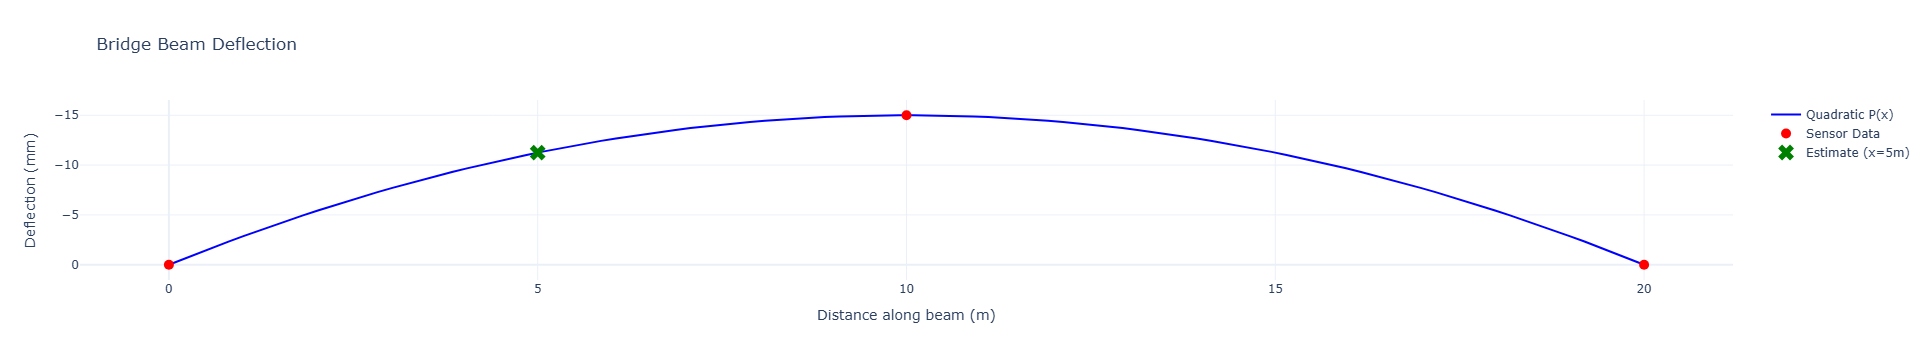

In [1]:
import numpy as np
import plotly.graph_objects as go

# --- Task 1 & 2: Set up and solve the system ---
A_prob1 = np.array([[0**2, 0, 1], [10**2, 10, 1], [20**2, 20, 1]])
b_prob1 = np.array([0, -15, 0])
a1, b1, c1 = np.linalg.solve(A_prob1, b_prob1)

# --- Task 3: Estimate the deflection at x = 5m ---
x_target, y_target = 5, a1*(5**2) + b1*5 + c1

# --- Interactive Data Visualization ---
x_curve = np.linspace(0, 20, 100)
y_curve = a1 * (x_curve**2) + b1 * x_curve + c1

fig = go.Figure()
fig.add_trace(go.Scatter(x=x_curve, y=y_curve, mode='lines', name='Quadratic P(x)', line=dict(color='blue', width=2)))
fig.add_trace(go.Scatter(x=[0, 10, 20], y=[0, -15, 0], mode='markers', name='Sensor Data', marker=dict(color='red', size=10)))
fig.add_trace(go.Scatter(x=[x_target], y=[y_target], mode='markers', name=f'Estimate (x=5m)', marker=dict(color='green', symbol='x', size=14)))

fig.update_layout(
    title='Bridge Beam Deflection',
    xaxis_title='Distance along beam (m)',
    yaxis_title='Deflection (mm)',
    yaxis=dict(autorange="reversed"),
    template="plotly_white",
    dragmode='pan' # <--- This makes left-click pan the graph
)
fig.show(config={'scrollZoom': True})

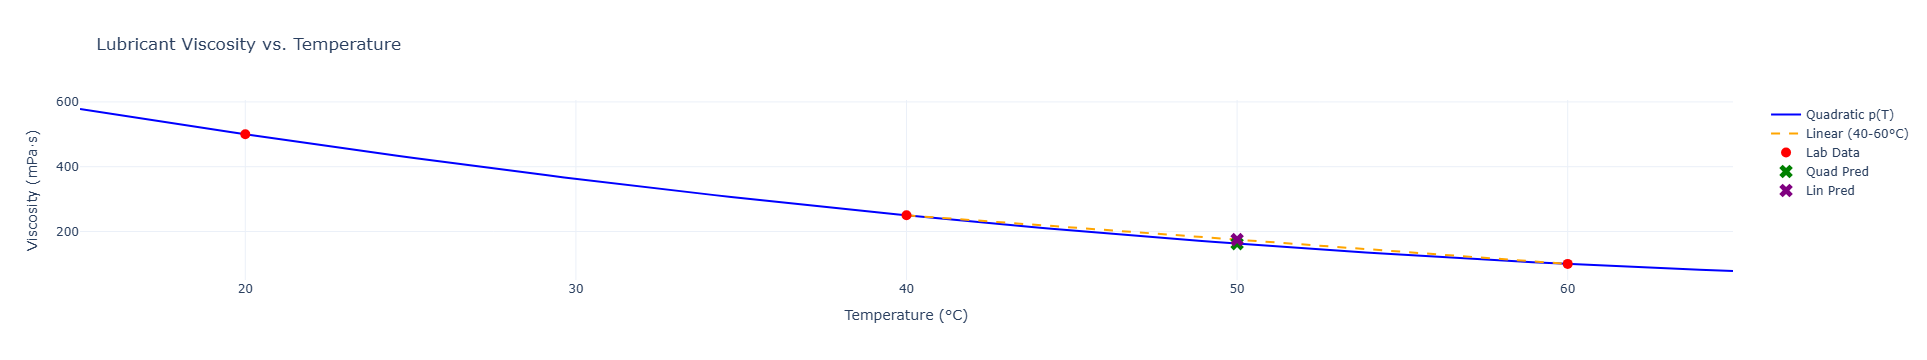

In [2]:
import numpy as np
import plotly.graph_objects as go

# --- Task 1: Solve for quadratic polynomial ---
T_data, u_data = np.array([20, 40, 60]), np.array([500, 250, 100])
A_prob2 = np.array([[T_data[0]**2, T_data[0], 1], [T_data[1]**2, T_data[1], 1], [T_data[2]**2, T_data[2], 1]])
a2, b2, c2 = np.linalg.solve(A_prob2, u_data)

# --- Task 2 & 3: Predictions ---
T_target = 50
u_quad_pred = a2 * (T_target**2) + b2 * T_target + c2
u_linear_pred = ((100 - 250) / (60 - 40)) * (T_target - 40) + 250

# --- Interactive Data Visualization ---
t_curve = np.linspace(15, 65, 100)
u_curve = a2 * (t_curve**2) + b2 * t_curve + c2

fig = go.Figure()
fig.add_trace(go.Scatter(x=t_curve, y=u_curve, mode='lines', name='Quadratic p(T)', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=[40, 60], y=[250, 100], mode='lines', name='Linear (40-60°C)', line=dict(color='orange', dash='dash')))
fig.add_trace(go.Scatter(x=T_data, y=u_data, mode='markers', name='Lab Data', marker=dict(color='red', size=10)))
fig.add_trace(go.Scatter(x=[T_target], y=[u_quad_pred], mode='markers', name=f'Quad Pred', marker=dict(color='green', symbol='x', size=12)))
fig.add_trace(go.Scatter(x=[T_target], y=[u_linear_pred], mode='markers', name=f'Lin Pred', marker=dict(color='purple', symbol='x', size=12)))

fig.update_layout(
    title='Lubricant Viscosity vs. Temperature',
    xaxis_title='Temperature (°C)',
    yaxis_title='Viscosity (mPa·s)',
    template="plotly_white",
    dragmode='pan' # <--- This makes left-click pan the graph
)
fig.show(config={'scrollZoom': True})

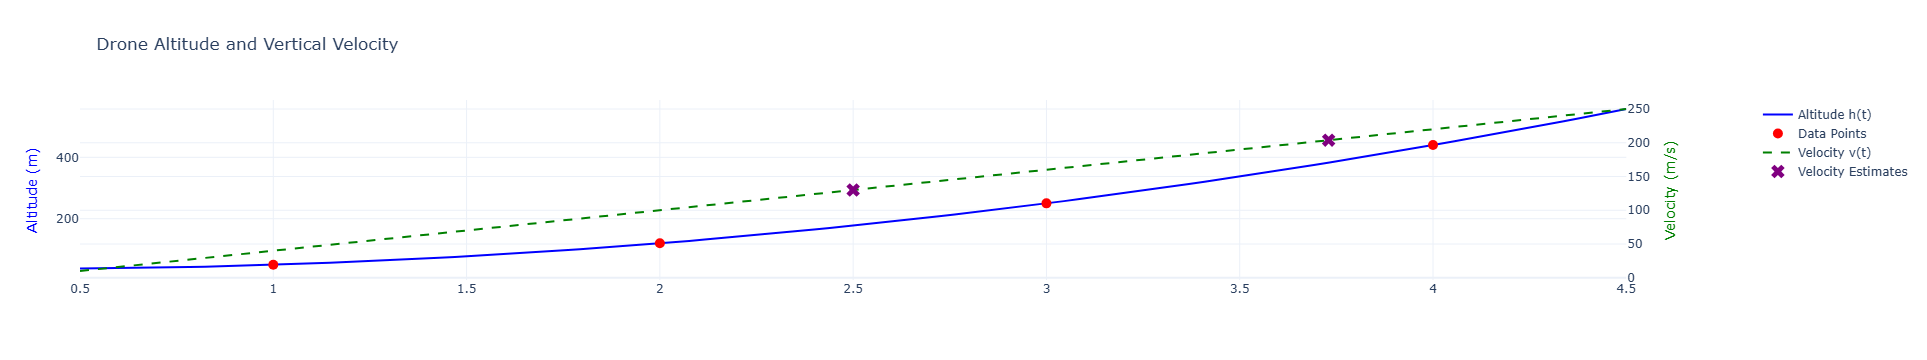

In [3]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- Task 1 & 2: Solve the cubic polynomial ---
t_data, h_data = np.array([1, 2, 3, 4]), np.array([50, 120, 250, 440])
A_prob3 = np.array([[t**3, t**2, t, 1] for t in t_data])
a3, a2, a1, a0 = np.linalg.solve(A_prob3, h_data)

# --- Task 3: Velocity Estimates ---
def velocity(t): return 3 * a3 * (t**2) + 2 * a2 * t + a1
v1, v2 = velocity(2.5), velocity(3.73)

# --- Interactive Data Visualization ---
t_curve = np.linspace(0.5, 4.5, 100)
h_curve = a3*(t_curve**3) + a2*(t_curve**2) + a1*t_curve + a0
v_curve = velocity(t_curve)

fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=t_curve, y=h_curve, mode='lines', name='Altitude h(t)', line=dict(color='blue')), secondary_y=False)
fig.add_trace(go.Scatter(x=t_data, y=h_data, mode='markers', name='Data Points', marker=dict(color='red', size=10)), secondary_y=False)
fig.add_trace(go.Scatter(x=t_curve, y=v_curve, mode='lines', name="Velocity v(t)", line=dict(color='green', dash='dash')), secondary_y=True)
fig.add_trace(go.Scatter(x=[2.5, 3.73], y=[v1, v2], mode='markers', name='Velocity Estimates', marker=dict(color='purple', symbol='x', size=12)), secondary_y=True)

fig.update_layout(
    title_text='Drone Altitude and Vertical Velocity', 
    template="plotly_white", 
    dragmode='pan' # <--- This makes left-click pan the graph
)
fig.update_yaxes(title_text="Altitude (m)", secondary_y=False, title_font=dict(color="blue"))
fig.update_yaxes(title_text="Velocity (m/s)", secondary_y=True, title_font=dict(color="green"))

fig.show(config={'scrollZoom': True})

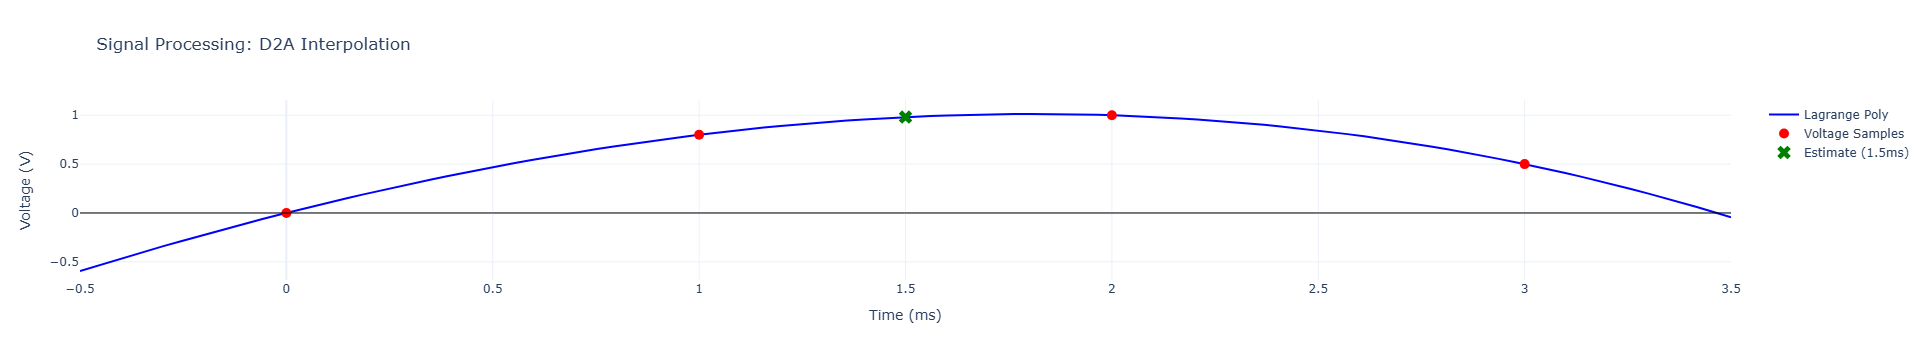

In [4]:
import numpy as np
import plotly.graph_objects as go
from scipy.interpolate import lagrange

# --- Task 1: Find polynomial ---
t_data, v_data = np.array([0, 1, 2, 3]), np.array([0.0, 0.8, 1.0, 0.5])
poly_lagrange = lagrange(t_data, v_data)

# --- Task 2: Estimated voltage ---
t_target, v_target = 1.5, poly_lagrange(1.5)

# --- Interactive Data Visualization ---
t_curve = np.linspace(-0.5, 3.5, 100)
v_curve = poly_lagrange(t_curve)

fig = go.Figure()
fig.add_trace(go.Scatter(x=t_curve, y=v_curve, mode='lines', name='Lagrange Poly', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=t_data, y=v_data, mode='markers', name='Voltage Samples', marker=dict(color='red', size=10)))
fig.add_trace(go.Scatter(x=[t_target], y=[v_target], mode='markers', name=f'Estimate (1.5ms)', marker=dict(color='green', symbol='x', size=12)))
fig.add_hline(y=0, line_width=1, line_color="black")

fig.update_layout(
    title='Signal Processing: D2A Interpolation',
    xaxis_title='Time (ms)', yaxis_title='Voltage (V)', 
    template="plotly_white",
    dragmode='pan' # <--- This makes left-click pan the graph
)
fig.show(config={'scrollZoom': True})

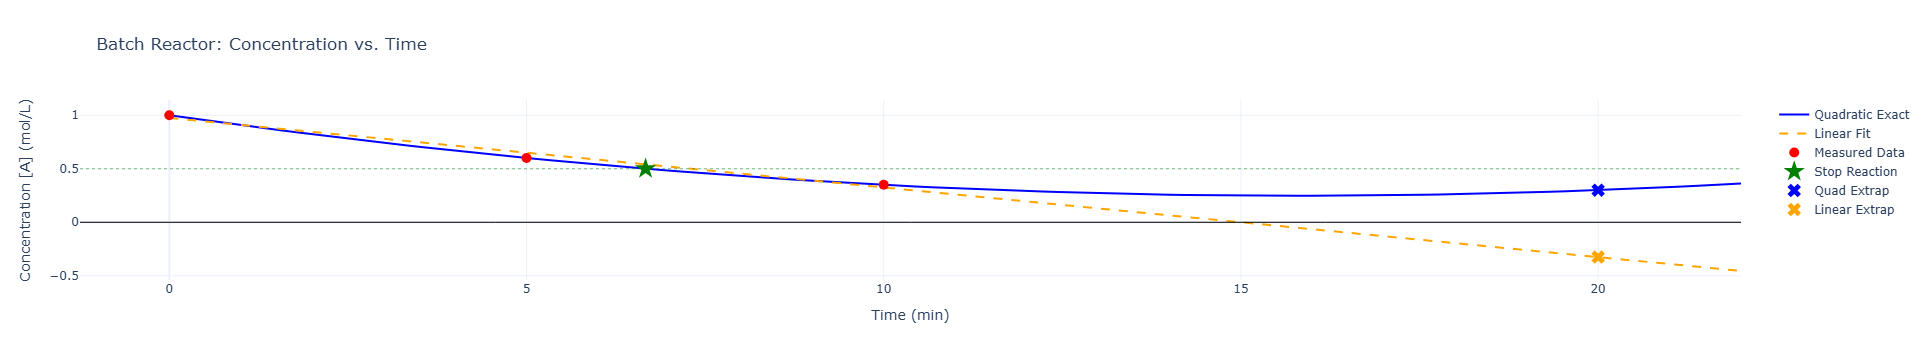

In [5]:
import numpy as np
import plotly.graph_objects as go

# --- Task 1: Construct polynomial C(t) ---
t_data, C_data = np.array([0, 5, 10]), np.array([1.00, 0.60, 0.35])
A_prob5 = np.array([[t_data[0]**2, t_data[0], 1], [t_data[1]**2, t_data[1], 1], [t_data[2]**2, t_data[2], 1]])
a5, b5, c5 = np.linalg.solve(A_prob5, C_data)

# --- Task 2: Estimate time when concentration is 0.50 ---
target_C = 0.50
roots = np.roots([a5, b5, c5 - target_C])
valid_time = [r for r in roots if 0 <= r <= 10][0]

# --- Task 3: Compare to Linear fit ---
m, b_lin = np.polyfit(t_data, C_data, 1)
t_future = 20
C_quad_future = a5*(t_future**2) + b5*t_future + c5
C_lin_future = m*t_future + b_lin

# --- Interactive Data Visualization ---
t_curve = np.linspace(0, 22, 100)
C_quad_curve, C_lin_curve = a5*(t_curve**2) + b5*t_curve + c5, m*t_curve + b_lin

fig = go.Figure()
fig.add_trace(go.Scatter(x=t_curve, y=C_quad_curve, mode='lines', name='Quadratic Exact', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=t_curve, y=C_lin_curve, mode='lines', name='Linear Fit', line=dict(color='orange', dash='dash')))
fig.add_trace(go.Scatter(x=t_data, y=C_data, mode='markers', name='Measured Data', marker=dict(color='red', size=10)))
fig.add_trace(go.Scatter(x=[valid_time], y=[target_C], mode='markers', name=f'Stop Reaction', marker=dict(color='green', symbol='star', size=16)))
fig.add_trace(go.Scatter(x=[t_future], y=[C_quad_future], mode='markers', name='Quad Extrap', marker=dict(color='blue', symbol='x', size=12)))
fig.add_trace(go.Scatter(x=[t_future], y=[C_lin_future], mode='markers', name='Linear Extrap', marker=dict(color='orange', symbol='x', size=12)))

fig.add_hline(y=0, line_width=1, line_color="black")
fig.add_hline(y=target_C, line_width=1, line_dash="dot", line_color="green", opacity=0.5)

fig.update_layout(
    title='Batch Reactor: Concentration vs. Time',
    xaxis_title='Time (min)', yaxis_title='Concentration [A] (mol/L)', 
    template="plotly_white",
    dragmode='pan' # <--- This makes left-click pan the graph
)
fig.show(config={'scrollZoom': True})